# 2D Mesh Sensitivity Analysis

## Overview

This notebook demonstrates **end-to-end 2D mesh sensitivity analysis** using the `GeomMesh` API.
For any 2D HEC-RAS model, mesh resolution is a critical modeling choice that directly affects:

- **Accuracy**: Finer meshes resolve terrain and flow features better
- **Runtime**: Cell count drives computation time (roughly quadratic with cell size reduction)
- **Stability**: Too-fine meshes near breaklines can cause solver instability
- **Calibration**: Mesh resolution can affect calibrated Manning's n values

### What This Notebook Does

1. Extracts the **BaldEagleCrkMulti2D** example project (Plan 06, Geometry 09)
2. Clones the geometry for each sensitivity scenario
3. Varies mesh parameters systematically:
   - **Base cell size** (coarse → fine)
   - **Breakline spacing** (all breaklines, near and far)
   - **Selective breakline spacing** (dam breakline only vs. channel breaklines)
4. Regenerates meshes using `GeomMesh.generate()`
5. Clones plans pointing to each modified geometry
6. Executes all plans
7. Generates WSE stored maps and compares results

### Mesh Parameters Explained

| Parameter | Text File Field | Default | Effect |
|-----------|----------------|---------|--------|
| `cell_size` | `Storage Area Point Generation Data=,,X,X` | `None` (auto-detect from HDF `Spacing dx`) | Base grid spacing for seed points |
| `bl_spacing_near` | `BreakLine CellSize Min=` | `None` (preserve text) | Cell size immediately adjacent to breaklines |
| `bl_spacing_far` | `BreakLine CellSize Max=` | `None` (preserve text) | Cell size at transition distance from breaklines |

### Cell Size Auto-Detection

When `cell_size=None` (the default), `GeomMesh.generate()` reads the model's own spacing from
the compiled geometry HDF attribute `Spacing dx`. This ensures headless mesh generation
reproduces the original model's cell count without requiring the caller to know the spacing.

Pass an explicit `cell_size` to override — this is what sensitivity analysis does.

### Reference

- [HEC-RAS 2D User Manual: Section 3.4 - Mesh Generation](https://www.hec.usace.army.mil/software/hec-ras/documentation.aspx)
- [Brunner (2016) Combined 1D and 2D Modeling with HEC-RAS](https://www.hec.usace.army.mil/publications/)

## Setup

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = True  # <-- TOGGLE THIS

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    from pathlib import Path
    print("PIP PACKAGE MODE: Loading installed ras-commander")

from ras_commander import (
    init_ras_project, RasExamples, RasPlan, RasCmdr,
    RasProcess, RasMap,
)
from ras_commander.geom.GeomMesh import GeomMesh

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import ras_commander
print(f"Loaded: {ras_commander.__file__}")

LOCAL SOURCE MODE: Loading from G:\GH\ras-commander/ras_commander


Loaded: G:\GH\ras-commander\ras_commander\__init__.py


## Parameters

Configure these values for your project. The defaults use BaldEagleCrkMulti2D Plan 06
("Gridded Precip - Infiltration") with Geometry 09 ("Single 2D Area - Internal Dam Structure").

In [ ]:
# =============================================================================
# PARAMETERS
# =============================================================================

PROJECT_NAME = "BaldEagleCrkMulti2D"
RAS_VERSION = "6.6"
TEMPLATE_PLAN = "06"
SUFFIX = "230_mesh_sens"

# Mesh sensitivity scenarios — each dict becomes one geometry clone + plan
#
# The baseline geometry (g09) uses:
#   cell_size = 250 (feet)   — from "Storage Area Point Generation Data=,,250,250"
#   breakline spacing = not set (empty CellSize Min/Max on all 4 breaklines)
#
# Breaklines in g09:  SayersDam, Lower, Middle, Upper
#
# NOTE: Each scenario passes an explicit cell_size to override auto-detection.
# If cell_size is omitted (or None), GeomMesh.generate() auto-detects from
# the compiled HDF's Spacing dx attribute (250 ft for this geometry).

SCENARIOS = [
    # —— Group 1: Base cell size variation ——
    {
        "name": "coarse_500",
        "title": "Coarse 500ft",
        "cell_size": 500.0,
    },
    {
        "name": "baseline_250",
        "title": "Baseline 250ft",
        "cell_size": 250.0,
    },
    {
        "name": "fine_150",
        "title": "Fine 150ft",
        "cell_size": 150.0,
    },

    # —— Group 2: Breakline spacing (all breaklines) ——
    {
        "name": "bl_tight",
        "title": "BL Near=50 Far=150",
        "cell_size": 250.0,
        "bl_spacing_near": 50.0,
        "bl_spacing_far": 150.0,
    },
    {
        "name": "bl_moderate",
        "title": "BL Near=100 Far=200",
        "cell_size": 250.0,
        "bl_spacing_near": 100.0,
        "bl_spacing_far": 200.0,
    },

    # —— Group 3: Combined fine mesh + tight breaklines ——
    {
        "name": "fine_bl_tight",
        "title": "Fine 150ft + BL 50/150",
        "cell_size": 150.0,
        "bl_spacing_near": 50.0,
        "bl_spacing_far": 150.0,
    },
]

# Execution settings
NUM_CORES = 4
MAX_WORKERS = 2

# Point of interest for time-series extraction (project coordinates)
POINT_OF_INTEREST = (2081544, 365715)

## Extract Project and Initialize

In [3]:
project_folder = RasExamples.extract_project(PROJECT_NAME, suffix=SUFFIX)
ras = init_ras_project(project_folder, RAS_VERSION)

print(f"Project: {project_folder}")
print(f"\nPlans:")
print(ras.plan_df[['plan_number', 'Plan Title', 'Short Identifier']].to_string(index=False))
print(f"\nGeometries:")
print(ras.geom_df[['geom_number', 'geom_title']].to_string(index=False))

2026-04-22 16:51:48 - ras_commander.RasExamples - INFO - Found zip file: C:\Users\bill\AppData\Local\ras-commander\examples\Example_Projects_7_0.zip


2026-04-22 16:51:48 - ras_commander.RasExamples - INFO - Loading project data from CSV...


2026-04-22 16:51:48 - ras_commander.RasExamples - INFO - Loaded 67 projects from CSV.


2026-04-22 16:51:48 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-22 16:51:48 - ras_commander.RasExamples - INFO - Extracting project 'BaldEagleCrkMulti2D' as 'BaldEagleCrkMulti2D_230_mesh_sens'


...

2026-04-22 16:51:50 - ras_commander.RasPrj - INFO - Updated results_df with 11 plan(s)


2026-04-22 16:51:50 - ras_commander.RasPrj - INFO - ras-commander v0.94.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-04-22 16:51:50 - ras_commander.RasPrj - INFO - Project initialized: BaldEagleDamBrk | Folder: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens


2026-04-22 16:51:50 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


Project: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens

Plans:
plan_number                              Plan Title         Short Identifier
         13                 PMF with Multi 2D Areas             PMF Multi 2D
         15             1d-2D Dambreak Refined Grid       1D-2D Refined Grid
         17                         2D to 1D No Dam          2D to 1D No Dam
         18                            2D to 2D Run             2D to 2D Run
         19                  SA to 2D Dam Break Run       SA to 2D Dam Break
         03 Single 2D Area - Internal Dam Structure                Single 2D
         04 SA to 2D Area Conn - 2D Levee Structure           2D Levee Struc
         02                SA to Detailed 2D Breach           SA-2D Det Brch
         01            SA to Detailed 2D Breach FEQ            SA-2D Det FEQ
         05         Single 2D area with Bridges FEQ    Single 2D Bridges FEQ
         06           Gridded Precip - Infiltration Grid

## Inspect Baseline Geometry

Read the breakline configuration from the template geometry (g09) before cloning.

In [ ]:
# Get the geometry number from the template plan
template_geom = ras.plan_df.loc[
    ras.plan_df['plan_number'] == TEMPLATE_PLAN, 'geometry_number'
].values[0]
template_geom_path = Path(
    ras.geom_df.loc[
        ras.geom_df['geom_number'] == template_geom, 'full_path'
    ].values[0]
)

print(f"Template plan: {TEMPLATE_PLAN}")
print(f"Template geometry: g{template_geom} ({template_geom_path.name})")

# ── Inspect breakline names and spacing using the GeomMesh API ──
# get_breakline_names() returns (fid, name) tuples — FID is the 0-based index
# and the most reliable identifier since HEC-RAS allows duplicate/empty names.
bl_names = GeomMesh.get_breakline_names(template_geom_path)
print(f"\nBreaklines ({len(bl_names)}):")
for fid, name in bl_names:
    label = name if name else "(unnamed)"
    print(f"  FID {fid}: {label}")

# get_breakline_spacing() returns full per-breakline properties
bl_spacing = GeomMesh.get_breakline_spacing(template_geom_path)
print(f"\nBreakline spacing:")
print(f"  {'FID':<5} {'Name':<15} {'Near':>8} {'Far':>8} {'NR':>4} {'PR':>4}")
print(f"  {'-'*5} {'-'*15} {'-'*8} {'-'*8} {'-'*4} {'-'*4}")
for fid, name, near, far, nr, pr in bl_spacing:
    near_s = f"{near:.1f}" if near else "(none)"
    far_s = f"{far:.1f}" if far else "(none)"
    print(f"  {fid:<5} {name:<15} {near_s:>8} {far_s:>8} {nr:>4} {pr:>4}")

# Read base cell size from text
text = template_geom_path.read_text(encoding='utf-8', errors='replace')
for line in text.splitlines():
    if line.startswith('Storage Area Point Generation Data='):
        print(f"\nBase cell size: {line}")
        break

## Breakline Name Management and Per-Breakline Spacing

The `GeomMesh` API supports **per-breakline targeting** by name or FID (0-based index).
HEC-RAS allows duplicate and empty breakline names, so FID is the most reliable selector.

| Method | Purpose |
|--------|---------|
| `get_breakline_names()` | List all breakline (fid, name) tuples |
| `set_breakline_name()` | Rename a breakline by FID or old name |
| `get_breakline_spacing()` | Read per-breakline spacing properties |
| `set_breakline_spacing()` | Set spacing for one breakline, or all at once |

### Targeting Modes

- **By name**: `set_breakline_spacing(geom, near=50, breakline_name="SayersDam")`
- **By FID**: `set_breakline_spacing(geom, near=50, breakline_fid=0)` — preferred for unnamed breaklines
- **Bulk**: `set_breakline_spacing(geom, near=50, all_breaklines=True)` — model building & sensitivity

In [ ]:
# ── Example: Rename a breakline by FID ──
# Clone the geometry so we don't modify the template
demo_geom = RasPlan.clone_geom(template_geom, ras_object=ras)
demo_geom_path = Path(
    ras.geom_df.loc[
        ras.geom_df['geom_number'] == demo_geom, 'full_path'
    ].values[0]
)

print("Before rename:")
for fid, name in GeomMesh.get_breakline_names(demo_geom_path):
    print(f"  FID {fid}: {name}")

# Rename SayersDam breakline by FID (most reliable for unnamed breaklines)
GeomMesh.set_breakline_name(demo_geom_path, new_name="Sayers_Dam_Crest", breakline_fid=0)

# Rename by old name (works when names are unique)
GeomMesh.set_breakline_name(demo_geom_path, new_name="Lower_Channel", old_name="Lower")

print("\nAfter rename:")
for fid, name in GeomMesh.get_breakline_names(demo_geom_path):
    print(f"  FID {fid}: {name}")

# ── Example: Per-breakline spacing ──
# Set tight spacing on the dam breakline only (by name)
GeomMesh.set_breakline_spacing(
    demo_geom_path,
    near=25.0, far=100.0,
    near_repeats=2,
    protection_radius=1,
    breakline_name="Sayers_Dam_Crest",
)

# Set moderate spacing on channel breaklines (by FID)
for fid in [1, 2, 3]:  # Lower_Channel, Middle, Upper
    GeomMesh.set_breakline_spacing(
        demo_geom_path,
        near=75.0, far=200.0,
        breakline_fid=fid,
    )

print("\nPer-breakline spacing after edits:")
print(f"  {'FID':<5} {'Name':<20} {'Near':>8} {'Far':>8} {'NR':>4} {'PR':>4}")
print(f"  {'-'*5} {'-'*20} {'-'*8} {'-'*8} {'-'*4} {'-'*4}")
for fid, name, near, far, nr, pr in GeomMesh.get_breakline_spacing(demo_geom_path):
    print(f"  {fid:<5} {name:<20} {near:>8.1f} {far:>8.1f} {nr:>4} {pr:>4}")

# ── Example: Bulk spacing for sensitivity analysis ──
# Set all breaklines to the same spacing at once
GeomMesh.set_breakline_spacing(
    demo_geom_path,
    near=50.0, far=150.0,
    all_breaklines=True,
)
print("\nAfter bulk set (all_breaklines=True):")
for fid, name, near, far, nr, pr in GeomMesh.get_breakline_spacing(demo_geom_path):
    print(f"  FID {fid} ({name}): near={near:.1f}, far={far:.1f}")

## Refinement Region Management

Refinement regions override the base cell size within polygon boundaries. They are stored
in the compiled HDF (not .g## text), so the API operates on the HDF directly.

| Method | Purpose |
|--------|---------|
| `get_refinement_region_names()` | List all region (fid, name) tuples from HDF |
| `set_refinement_region_name()` | Rename a region by FID or old name |
| `get_refinement_regions()` | Read per-region spacing (fid, name, dx, dy) |
| `set_refinement_region_spacing()` | Set spacing for one region, or all at once |

Like breaklines, HEC-RAS allows duplicate and empty refinement region names —
use FID for reliable targeting.

**Note**: The BaldEagleCrkMulti2D example does not contain refinement regions,
so the API calls below will return empty results. The pattern is shown for reference.

In [ ]:
# ── Refinement region inspection ──
# These methods read from the compiled HDF. If the HDF doesn't exist,
# it will be compiled automatically from the .g## text file.

rr_names = GeomMesh.get_refinement_region_names(demo_geom_path)
print(f"Refinement regions: {len(rr_names)}")
for fid, name in rr_names:
    label = name if name else "(unnamed)"
    print(f"  FID {fid}: {label}")

rr_details = GeomMesh.get_refinement_regions(demo_geom_path)
if rr_details:
    print(f"\n  {'FID':<5} {'Name':<20} {'dx':>10} {'dy':>10}")
    print(f"  {'-'*5} {'-'*20} {'-'*10} {'-'*10}")
    for rr in rr_details:
        print(f"  {rr['fid']:<5} {rr['name']:<20} {rr['spacing_dx']:>10.1f} {rr['spacing_dy']:>10.1f}")
else:
    print("  (none in this geometry)")

# ── API usage pattern (for geometries that have refinement regions) ──
# These calls would work on a geometry with refinement regions:
#
# Rename by FID:
#   GeomMesh.set_refinement_region_name(geom_path, "Urban_Core", region_fid=0)
#
# Rename by old name (raises ValueError if duplicates exist):
#   GeomMesh.set_refinement_region_name(geom_path, "Floodplain_Fine", old_name="Region1")
#
# Set spacing for a single region by name:
#   GeomMesh.set_refinement_region_spacing(geom_path, spacing_dx=50.0, region_name="Urban_Core")
#
# Set spacing by FID (most reliable):
#   GeomMesh.set_refinement_region_spacing(geom_path, spacing_dx=50.0, region_fid=0)
#
# Bulk set all regions (sensitivity analysis):
#   GeomMesh.set_refinement_region_spacing(geom_path, spacing_dx=25.0, all_regions=True)

## Clone Geometries and Generate Meshes

For each scenario, clone the template geometry, apply breakline spacing via the API,
generate the mesh, and clone a plan pointing to the new geometry.

In [ ]:
scenario_results = []

for scenario in SCENARIOS:
    name = scenario["name"]
    title = scenario["title"]
    cell_size = scenario.get("cell_size", 250.0)
    bl_near = scenario.get("bl_spacing_near")
    bl_far = scenario.get("bl_spacing_far")
    bl_by_name = scenario.get("bl_by_name")  # optional per-breakline dict

    print(f"\n{'='*60}")
    print(f"Scenario: {title}")
    print(f"  cell_size={cell_size}, bl_near={bl_near}, bl_far={bl_far}")

    # 1. Clone geometry (copies both .g## text and .g##.hdf)
    new_geom = RasPlan.clone_geom(template_geom, ras_object=ras)
    print(f"  Cloned geometry: g{template_geom} -> g{new_geom}")

    # Get the new geometry's text file path
    new_geom_path = Path(
        ras.geom_df.loc[
            ras.geom_df['geom_number'] == new_geom, 'full_path'
        ].values[0]
    )

    # 2. Apply per-breakline spacing if specified (using the API)
    if bl_by_name:
        for bl_name, (near_val, far_val) in bl_by_name.items():
            GeomMesh.set_breakline_spacing(
                new_geom_path,
                near=near_val, far=far_val,
                breakline_name=bl_name,
            )
            print(f"  Set breakline '{bl_name}': near={near_val}, far={far_val}")

    # 3. Generate mesh (cell_size and breakline spacing applied internally)
    mesh_result = GeomMesh.generate(
        geom_number=new_geom_path,
        mesh_name="BaldEagleCr",
        cell_size=cell_size,
        bl_spacing_near=bl_near,
        bl_spacing_far=bl_far,
        max_iterations=8,
        ras_object=ras,
    )

    print(f"  Mesh: status={mesh_result.status}, "
          f"cells={mesh_result.cell_count}, faces={mesh_result.face_count}")
    if mesh_result.fixes_applied:
        print(f"  Fixes: {mesh_result.fixes_applied}")

    # 4. Clone plan and assign the new geometry
    new_plan = RasPlan.clone_plan(
        TEMPLATE_PLAN,
        new_plan_shortid=name[:12],
        geometry=new_geom,
        num_cores=NUM_CORES,
        ras_object=ras,
    )
    print(f"  Cloned plan: p{TEMPLATE_PLAN} -> p{new_plan} (geom=g{new_geom})")

    scenario_results.append({
        "name": name,
        "title": title,
        "plan_number": new_plan,
        "geom_number": new_geom,
        "cell_size": cell_size,
        "bl_near": bl_near,
        "bl_far": bl_far,
        "cell_count": mesh_result.cell_count,
        "face_count": mesh_result.face_count,
        "mesh_status": mesh_result.status,
        "fixes": mesh_result.fixes_applied,
    })

# Summary table
scenario_df = pd.DataFrame(scenario_results)
print(f"\n{'='*60}")
print("Scenario Summary:")
print(scenario_df[['name', 'plan_number', 'geom_number', 'cell_size',
                    'bl_near', 'bl_far', 'cell_count', 'face_count', 'mesh_status'
                    ]].to_string(index=False))

## Mesh Reproduction Validation

Before executing plans, verify the baseline scenario reproduces the original mesh.
RegenerateMeshPoints uses the same grid origin as RAS Mapper: same HEC-RAS version and
cell size produces identical cell centers to machine precision.

### Auto-Detection vs Explicit Cell Size

`GeomMesh.generate()` defaults to `cell_size=None`, which reads `Spacing dx` from the
compiled geometry HDF. This produces the same mesh as the original model without the caller
needing to know the spacing. In sensitivity analysis (above) we override with explicit values.

The cell below demonstrates both: auto-detect for reproduction fidelity, then compares
against the explicit baseline scenario.

In [ ]:
import h5py
from scipy.spatial import cKDTree

# ── Auto-detect demonstration ──────────────────────────────────────────────
# Clone a fresh geometry and generate with cell_size=None (auto-detect)
auto_geom = RasPlan.clone_geom(template_geom, ras_object=ras)
auto_geom_path = Path(
    ras.geom_df.loc[
        ras.geom_df["geom_number"] == auto_geom, "full_path"
    ].values[0]
)

auto_result = GeomMesh.generate(
    geom_number=auto_geom_path,
    mesh_name="BaldEagleCr",
    cell_size=None,  # auto-detect from HDF Spacing dx
    max_iterations=8,
    ras_object=ras,
)
print(f"Auto-detect result: {auto_result.cell_count:,} cells "
      f"(cell_size read from HDF Spacing dx)")

# Read original and auto-detect cell centers
orig_hdf = Path(str(template_geom_path) + ".hdf")
auto_hdf = Path(str(auto_geom_path) + ".hdf")

with h5py.File(str(orig_hdf), "r") as f:
    orig_cc = f["Geometry/2D Flow Areas/BaldEagleCr/Cells Center Coordinate"][:]

with h5py.File(str(auto_hdf), "r") as f:
    auto_cc = f["Geometry/2D Flow Areas/BaldEagleCr/Cells Center Coordinate"][:]

# Also read the text seed count written by generate()
auto_text = auto_geom_path.read_text(encoding="utf-8", errors="replace")
auto_text_seeds = None
for line in auto_text.splitlines():
    if line.startswith("Storage Area 2D Points="):
        auto_text_seeds = int(line.split("=", 1)[1].strip())
        break

print(f"\nOriginal g{template_geom} HDF cells: {orig_cc.shape[0]:,}")
print(f"Auto-detect regenerated:        {auto_cc.shape[0]:,}")
if auto_text_seeds is not None:
    print(f"Auto-detect text seed count:    {auto_text_seeds:,}")

# Spatial comparison
tree = cKDTree(orig_cc)
dists, _ = tree.query(auto_cc)
print()
print("Cell center distances (auto-detect vs original):")
print(f"  Max:    {dists.max():.6f} ft")
print(f"  Mean:   {dists.mean():.6f} ft")
print(f"  Median: {np.median(dists):.6f} ft")
exact = np.sum(dists < 0.01)
print(f"  Exact matches (<0.01 ft): {exact:,} / {len(dists):,}")

if orig_cc.shape[0] == auto_cc.shape[0] and dists.max() < 0.01:
    print("\nEXACT MATCH: Auto-detected cell size reproduces original mesh perfectly")
elif orig_cc.shape[0] == auto_cc.shape[0]:
    print(f"\nSame count, {np.sum(dists >= 0.01):,} cells shifted (cross-version delta)")
else:
    pct = 100 * min(orig_cc.shape[0], auto_cc.shape[0]) / max(orig_cc.shape[0], auto_cc.shape[0])
    print(f"\nCell count delta: {abs(orig_cc.shape[0] - auto_cc.shape[0]):,} "
          f"({pct:.1f}% overlap, cross-version mesh difference)")

# ── Compare with explicit baseline scenario ────────────────────────────────
baseline = next(s for s in scenario_results if s["name"] == "baseline_250")
print(f"\nExplicit baseline_250 cells: {baseline['cell_count']:,}")
print(f"Auto-detect cells:           {auto_result.cell_count:,}")
if baseline["cell_count"] == auto_result.cell_count:
    print("MATCH: Explicit cell_size=250 and auto-detect produce identical meshes")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.scatter(orig_cc[:, 0], orig_cc[:, 1], s=0.3, c="steelblue", alpha=0.3)
ax1.set_title(f"Original g{template_geom} ({orig_cc.shape[0]:,} cells)", fontsize=11)
ax1.set_xlabel("Easting (ft)")
ax1.set_ylabel("Northing (ft)")
ax1.set_aspect("equal")
ax1.grid(alpha=0.2)

ax2.scatter(auto_cc[:, 0], auto_cc[:, 1], s=0.3, c="darkorange", alpha=0.3)
ax2.set_title(f"Auto-detect regenerated ({auto_cc.shape[0]:,} cells)", fontsize=11)
ax2.set_xlabel("Easting (ft)")
ax2.set_ylabel("Northing (ft)")
ax2.set_aspect("equal")
ax2.grid(alpha=0.2)

for ax in [ax1, ax2]:
    ax.set_xlim(orig_cc[:, 0].min() - 500, orig_cc[:, 0].max() + 500)
    ax.set_ylim(orig_cc[:, 1].min() - 500, orig_cc[:, 1].max() + 500)

fig.suptitle("BaldEagleCr Mesh Reproduction: Original vs Auto-Detect Regenerated", fontsize=13)
plt.tight_layout()
plt.savefig(Path(project_folder) / "mesh_reproduction_validation.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("Mesh Generation Summary")
print("=" * 70)
rows = []
for s in scenario_results:
    fixes = ", ".join(s["fixes"]) if s.get("fixes") else "none"
    rows.append([s["name"], s["cell_count"], s["face_count"], s["mesh_status"], fixes])

hdr_fmt = "{:<20} {:>8} {:>8}   {:<10} {}"
row_fmt = "{:<20} {:>8,} {:>8,}   {:<10} {}"
print(hdr_fmt.format("Scenario", "Cells", "Faces", "Status", "Fixes"))
print("-" * 70)
for r in rows:
    print(row_fmt.format(*r))

baseline_text_path = Path(
    ras.geom_df.loc[
        ras.geom_df["geom_number"] == baseline["geom_number"], "full_path"
    ].values[0]
)
bt = baseline_text_path.read_text(encoding="utf-8", errors="replace")
for line in bt.splitlines():
    if line.startswith("Storage Area 2D Points="):
        text_seeds = int(line.split("=", 1)[1].strip())
        print()
        print(f"Baseline text seed count: {text_seeds:,}")
        print(f'Baseline cell_count:     {baseline["cell_count"]:,}')
        assert text_seeds == baseline["cell_count"], "Text/cell count mismatch!"
        print("Text seed count matches cell count: PASSED")
        break


Mesh Generation Summary
Scenario                Cells    Faces   Status     Fixes
----------------------------------------------------------------------
coarse_500              4,362    9,475   complete   none
baseline_250           17,905   37,319   complete   none
fine_150               50,281  103,048   complete   none
bl_tight               17,905   37,319   complete   none
bl_moderate            17,905   37,319   complete   none
fine_bl_tight          50,281  103,048   complete   none

Baseline text seed count: 17,905
Baseline cell_count:     17,905
Text seed count matches cell count: PASSED


## Execute Plans

Run all sensitivity scenarios. Plans are independent so we use parallel execution.

In [10]:
plan_numbers = [str(s['plan_number']) for s in scenario_results]
print(f"Executing {len(plan_numbers)} plans: {plan_numbers}")

exec_results = RasCmdr.compute_parallel(
    plan_number=plan_numbers,
    max_workers=MAX_WORKERS,
    num_cores=NUM_CORES,
    clear_geompre=True,
    ras_object=ras,
)

# Check actual solver status in result HDFs — compute_parallel may report
# success even when the unsteady solver fails internally.
import h5py

print("\nExecution results:")
for s in scenario_results:
    plan = s['plan_number']
    name = s['name']
    hdf_path = Path(project_folder) / f"{ras.project_name}.p{plan}.hdf"
    if hdf_path.exists():
        with h5py.File(str(hdf_path), 'r') as f:
            summ = f.get('Results/Unsteady/Summary')
            solution = summ.attrs.get('Solution', b'').decode() if summ else 'Unknown'
            s['solver_status'] = solution
    else:
        s['solver_status'] = 'No HDF'

    status_ok = 'Finished Successfully' in s.get('solver_status', '')
    s['solver_ok'] = status_ok
    marker = "OK" if status_ok else "FAILED"
    print(f"  Plan {plan} ({name}): {marker} -- {s['solver_status']}")

succeeded = [s for s in scenario_results if s.get('solver_ok')]
failed = [s for s in scenario_results if not s.get('solver_ok')]
print(f"\n{len(succeeded)} succeeded, {len(failed)} failed")
if failed:
    print("\nNote: Failures are typically caused by mesh-dependent structure connections.")
    print("When mesh resolution changes, cell elevations near structures shift,")
    print("which can invalidate gate/weir connections that require cell_elev < gate_elev.")

2026-04-22 16:52:13 - ras_commander.RasCmdr - INFO - Filtered plans to execute: ['07', '08', '09', '10', '11', '12']


2026-04-22 16:52:13 - ras_commander.RasCmdr - INFO - Adjusted max_workers to 2 based on the number of plans to compute: 6


2026-04-22 16:52:13 - ras_commander.RasCmdr - INFO - Created worker folder: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens [Worker 1]


Executing 6 plans: ['07', '08', '09', '10', '11', '12']


2026-04-22 16:52:13 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens [Worker 1]\BaldEagleDamBrk.rasmap


...

2026-04-22 16:54:00 - ras_commander.hdf.HdfResultsPlan - INFO - Simulation Duration (hours): 120.0


2026-04-22 16:54:00 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens\BaldEagleDamBrk.p12.hdf


2026-04-22 16:54:00 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens\BaldEagleDamBrk.p12.hdf


2026-04-22 16:54:00 - ras_commander.RasPrj - INFO - Updated results_df with 6 plan(s)



Execution results:
  Plan 07 (coarse_500): OK -- Unsteady Finished Successfully
  Plan 08 (baseline_250): FAILED -- Unsteady failed to run
  Plan 09 (fine_150): FAILED -- Unsteady failed to run
  Plan 10 (bl_tight): FAILED -- Unsteady failed to run
  Plan 11 (bl_moderate): FAILED -- Unsteady failed to run
  Plan 12 (fine_bl_tight): FAILED -- Unsteady failed to run

1 succeeded, 5 failed

Note: Failures are typically caused by mesh-dependent structure connections.
When mesh resolution changes, cell elevations near structures shift,
which can invalidate gate/weir connections that require cell_elev < gate_elev.


### Mesh-Dependent Structure Connection Failures

**Geometry g09** includes the Sayers Dam internal structure with Gate #1 at elevation 593.00 ft.
When mesh resolution changes, the cell nearest the gate connection has a different terrain-averaged
elevation. For finer meshes, this cell elevation can exceed the gate elevation, causing HEC-RAS
to reject the connection:

```
ERROR with Connection(s)
gate Gate #1  gate elev   593.00
cell    17615  cell elev   598.96
```

**This is a real mesh sensitivity finding** — it demonstrates that changing mesh resolution affects
not just hydraulic results but also model validity. In production, you would either:
- Adjust the gate/weir elevation to remain below the finest-mesh cell elevation
- Use a geometry without internal structures for pure mesh resolution comparison
- Accept that very fine meshes require structure connection review

The analysis below proceeds with whichever scenarios completed successfully.

## Generate Stored Maps (WSE)

Set the render mode and generate maximum WSE TIFs for each plan.

In [11]:
# Set consistent render mode for all stored maps
RasMap.set_water_surface_render_mode("horizontal", ras_object=ras)

wse_tifs = {}

for s in scenario_results:
    plan = s['plan_number']
    name = s['name']

    if not s.get('solver_ok'):
        print(f"Skipping plan {plan} ({name}): solver did not finish successfully")
        continue

    print(f"Generating stored maps for plan {plan} ({name})...")

    try:
        maps = RasProcess.store_maps(
            plan_number=plan,
            profile="Max",
            wse=True,
            depth=True,
            velocity=False,
            ras_object=ras,
        )
        if 'wse' in maps and maps['wse']:
            wse_tifs[name] = maps['wse'][0]
            print(f"  WSE: {maps['wse'][0]}")
        if 'depth' in maps and maps['depth']:
            print(f"  Depth: {maps['depth'][0]}")
    except Exception as e:
        print(f"  ERROR: {e}")

print(f"\nGenerated {len(wse_tifs)} WSE TIFs")

2026-04-22 16:54:00 - ras_commander.RasMap - INFO - Set water surface render mode to 'horizontal'


2026-04-22 16:54:00 - ras_commander.RasMap - INFO - Updated RASMapper configuration: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens\BaldEagleDamBrk.rasmap


2026-04-22 16:54:00 - ras_commander.RasProcess - INFO - Created plan layer 'coarse_500' in rasmap for BaldEagleDamBrk.p07.hdf


2026-04-22 16:54:00 - ras_commander.RasProcess - INFO - Running StoreAllMaps for plan 07 (mode=horizontal)...


2026-04-22 16:54:00 - ras_commander._native_helper - INFO - Using staged RasStoreMapHelper runtime at C:\Users\bill\AppData\Local\ras-commander\bin\RasStoreMapHelper-0.94.0-d1a79dadb9b4-e002354b4799\RasStoreMapHelper.exe because the packaged helper has no sibling GDAL directory.


...

2026-04-22 16:54:06 - ras_commander.RasProcess - INFO - Generated 1 wse TIF(s)


2026-04-22 16:54:06 - ras_commander.RasProcess - INFO - Generated 1 depth TIF(s)


2026-04-22 16:54:06 - ras_commander.RasProcess - INFO - Fixed georeferencing: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens\coarse_500\WSE (Max).Terrain50.dtm_20ft.tif


2026-04-22 16:54:06 - ras_commander.RasProcess - INFO - Fixed georeferencing: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens\coarse_500\Depth (Max).Terrain50.dtm_20ft.tif


  WSE: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens\coarse_500\WSE (Max).Terrain50.dtm_20ft.tif
  Depth: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens\coarse_500\Depth (Max).Terrain50.dtm_20ft.tif
Skipping plan 08 (baseline_250): solver did not finish successfully
Skipping plan 09 (fine_150): solver did not finish successfully
Skipping plan 10 (bl_tight): solver did not finish successfully
Skipping plan 11 (bl_moderate): solver did not finish successfully
Skipping plan 12 (fine_bl_tight): solver did not finish successfully

Generated 1 WSE TIFs


## Compare WSE Maps

Load the WSE GeoTIFFs with rasterio and create side-by-side comparison figures
plus difference maps against the baseline.

In [12]:
import rasterio
from rasterio.plot import show


def load_wse(tif_path):
    """Load a WSE TIF, masking nodata."""
    with rasterio.open(tif_path) as src:
        data = src.read(1)
        nodata = src.nodata
        if nodata is not None:
            data = np.where(data == nodata, np.nan, data)
        else:
            data = np.where(data < -9000, np.nan, data)
        return data, src.bounds, src.transform


# Load all WSE rasters
wse_data = {}
for name, tif in wse_tifs.items():
    data, bounds, transform = load_wse(tif)
    wse_data[name] = {"data": data, "bounds": bounds, "transform": transform}
    valid = np.count_nonzero(~np.isnan(data))
    print(f"{name}: shape={data.shape}, valid_cells={valid:,}, "
          f"WSE range=[{np.nanmin(data):.1f}, {np.nanmax(data):.1f}]")

coarse_500: shape=(4852, 6705), valid_cells=949,554, WSE range=[535.8, 780.0]


C:\Users\bill\AppData\Local\Temp\ipykernel_22940\371487922.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


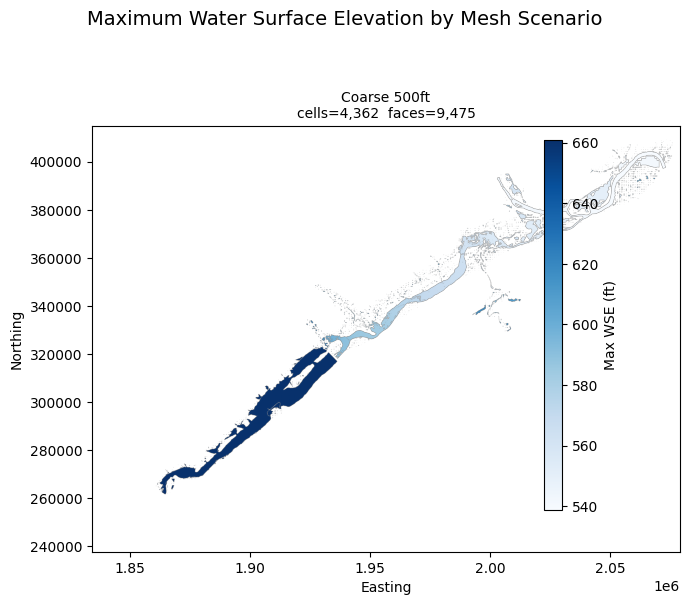

Saved: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens\wse_comparison.png


In [13]:
# â”€â”€ Side-by-side WSE maps â”€â”€
n = len(wse_data)
if n == 0:
    print("No WSE data to plot.")
else:
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Common color scale across all scenarios
    all_valid = np.concatenate(
        [d["data"][~np.isnan(d["data"])].ravel() for d in wse_data.values()]
    )
    vmin, vmax = np.percentile(all_valid, [2, 98])

    for ax, (name, d) in zip(axes, wse_data.items()):
        title_row = next(s for s in scenario_results if s['name'] == name)
        im = ax.imshow(
            d["data"],
            extent=[
                d["bounds"].left, d["bounds"].right,
                d["bounds"].bottom, d["bounds"].top,
            ],
            vmin=vmin, vmax=vmax,
            cmap="Blues",
            origin="upper",
        )
        ax.set_title(
            f"{title_row['title']}\n"
            f"cells={title_row['cell_count']:,}  faces={title_row['face_count']:,}",
            fontsize=10,
        )
        ax.set_xlabel("Easting")
        ax.set_ylabel("Northing")

    # Hide unused axes
    for ax in axes[n:]:
        ax.set_visible(False)

    fig.colorbar(im, ax=axes[:n], label="Max WSE (ft)", shrink=0.8)
    fig.suptitle("Maximum Water Surface Elevation by Mesh Scenario", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(Path(project_folder) / "wse_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {Path(project_folder) / 'wse_comparison.png'}")

## Difference Maps

Compute WSE differences relative to the baseline (250ft) scenario.
Positive values = scenario WSE is higher than baseline.

In [14]:
BASELINE_NAME = "baseline_250"

# Fall back to the first available scenario if baseline isn't in results
if BASELINE_NAME not in wse_data and wse_data:
    BASELINE_NAME = list(wse_data.keys())[0]
    print(f"Baseline scenario 'baseline_250' not available. Using '{BASELINE_NAME}' as reference.")

if BASELINE_NAME not in wse_data:
    print(f"No WSE data available for difference maps.")
else:
    baseline = wse_data[BASELINE_NAME]["data"]
    diff_scenarios = {k: v for k, v in wse_data.items() if k != BASELINE_NAME}

    n = len(diff_scenarios)
    if n == 0:
        print("Only one scenario available, no diffs to compute.")
    else:
        ncols = min(3, n)
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
        if n == 1:
            axes = [axes]
        else:
            axes = np.array(axes).flatten()

        # Symmetric color scale for differences
        all_diffs = []
        for name, d in diff_scenarios.items():
            other = d["data"]
            if other.shape == baseline.shape:
                diff = other - baseline
                valid_diff = diff[~np.isnan(diff)]
                if len(valid_diff) > 0:
                    all_diffs.append(valid_diff)

        if all_diffs:
            combined = np.concatenate(all_diffs)
            dmax = np.percentile(np.abs(combined), 98)
        else:
            dmax = 1.0

        for ax, (name, d) in zip(axes, diff_scenarios.items()):
            title_row = next(s for s in scenario_results if s['name'] == name)
            other = d["data"]

            if other.shape != baseline.shape:
                ax.text(0.5, 0.5, "Shape mismatch\nCannot compute diff",
                        ha="center", va="center", transform=ax.transAxes)
                ax.set_title(title_row['title'])
                continue

            diff = other - baseline

            im = ax.imshow(
                diff,
                extent=[
                    d["bounds"].left, d["bounds"].right,
                    d["bounds"].bottom, d["bounds"].top,
                ],
                vmin=-dmax, vmax=dmax,
                cmap="RdBu_r",
                origin="upper",
            )
            valid_diff = diff[~np.isnan(diff)]
            stats = (
                f"mean={np.mean(valid_diff):+.2f}  "
                f"max={np.max(valid_diff):+.2f}  "
                f"min={np.min(valid_diff):+.2f}"
            ) if len(valid_diff) > 0 else "no overlap"
            ax.set_title(f"{title_row['title']} - {BASELINE_NAME}\n{stats}", fontsize=10)
            ax.set_xlabel("Easting")
            ax.set_ylabel("Northing")

        for ax in axes[n:]:
            ax.set_visible(False)

        fig.colorbar(im, ax=list(axes[:n]), label="WSE Difference (ft)", shrink=0.8)
        fig.suptitle(
            f"WSE Difference from Reference ({BASELINE_NAME})",
            fontsize=14, y=1.02,
        )
        plt.tight_layout()
        plt.savefig(
            Path(project_folder) / "wse_diff_maps.png", dpi=150, bbox_inches="tight"
        )
        plt.show()
        print(f"Saved: {Path(project_folder) / 'wse_diff_maps.png'}")

Baseline scenario 'baseline_250' not available. Using 'coarse_500' as reference.
Only one scenario available, no diffs to compute.


## Mesh Resolution vs. Cell Count

Visualize how cell size affects mesh density and compare across scenarios.

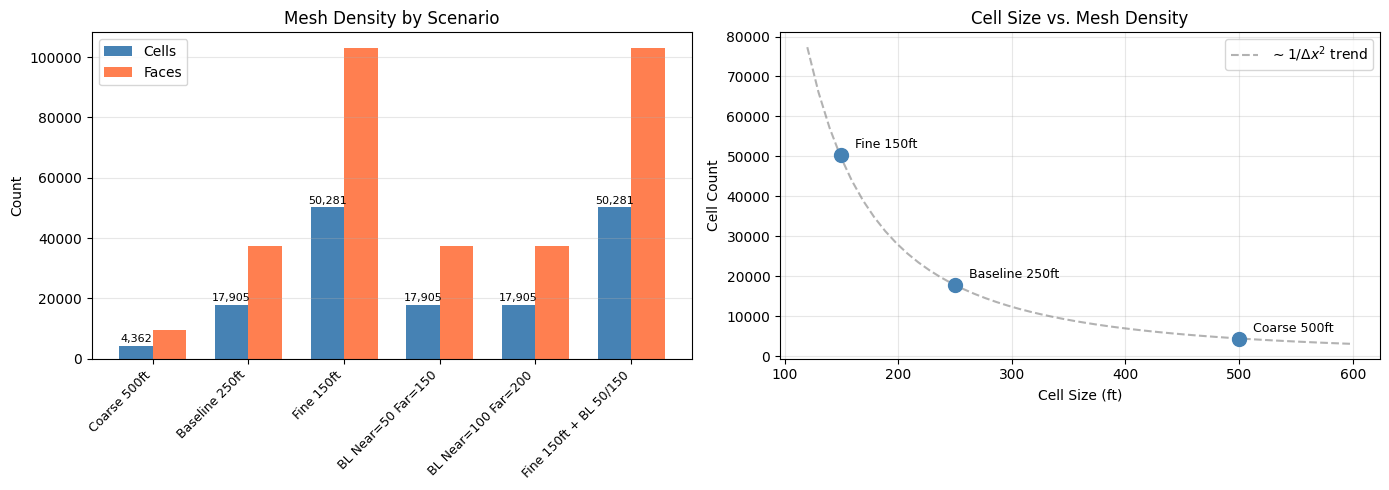

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: cell count by scenario
names = [s['title'] for s in scenario_results]
cells = [s['cell_count'] for s in scenario_results]
faces = [s['face_count'] for s in scenario_results]

x = np.arange(len(names))
width = 0.35

ax1.bar(x - width/2, cells, width, label='Cells', color='steelblue')
ax1.bar(x + width/2, faces, width, label='Faces', color='coral')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Count')
ax1.set_title('Mesh Density by Scenario')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for i, (c, f) in enumerate(zip(cells, faces)):
    ax1.text(i - width/2, c + max(cells) * 0.01, f'{c:,}',
             ha='center', va='bottom', fontsize=8)

# Scatter: cell_size vs cell_count for the cell-size group
cell_size_scenarios = [s for s in scenario_results if s.get('bl_near') is None]
if len(cell_size_scenarios) >= 2:
    cs = [s['cell_size'] for s in cell_size_scenarios]
    cc = [s['cell_count'] for s in cell_size_scenarios]
    ax2.scatter(cs, cc, s=100, c='steelblue', zorder=3)
    for s in cell_size_scenarios:
        ax2.annotate(s['title'], (s['cell_size'], s['cell_count']),
                     textcoords='offset points', xytext=(10, 5), fontsize=9)

    # Theoretical inverse-square fit
    cs_arr = np.array(cs, dtype=float)
    cc_arr = np.array(cc, dtype=float)
    k = np.mean(cc_arr * cs_arr**2)
    cs_fit = np.linspace(min(cs) * 0.8, max(cs) * 1.2, 50)
    ax2.plot(cs_fit, k / cs_fit**2, '--', color='gray', alpha=0.6,
             label=r'$\sim 1/\Delta x^2$ trend')
    ax2.legend()

ax2.set_xlabel('Cell Size (ft)')
ax2.set_ylabel('Cell Count')
ax2.set_title('Cell Size vs. Mesh Density')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(project_folder) / "mesh_density_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Results Summary Table

In [16]:
# Add WSE statistics and solver status to scenario results
summary_rows = []
for s in scenario_results:
    row = {
        "Scenario": s['title'],
        "Plan": f"p{s['plan_number']}",
        "Geom": f"g{s['geom_number']}",
        "Cell Size": s['cell_size'],
        "BL Near": s.get('bl_near', '-'),
        "BL Far": s.get('bl_far', '-'),
        "Cells": f"{s['cell_count']:,}",
        "Faces": f"{s['face_count']:,}",
        "Mesh": s['mesh_status'],
        "Solver": "OK" if s.get('solver_ok') else "FAILED",
    }
    if s['name'] in wse_data:
        d = wse_data[s['name']]['data']
        valid = d[~np.isnan(d)]
        row["Max WSE"] = f"{np.nanmax(valid):.1f}"
        row["Mean WSE"] = f"{np.nanmean(valid):.1f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# Save to CSV
csv_path = Path(project_folder) / "mesh_sensitivity_summary.csv"
summary_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

              Scenario Plan Geom  Cell Size  BL Near  BL Far  Cells   Faces     Mesh Solver Max WSE Mean WSE
          Coarse 500ft  p07  g04      500.0      NaN     NaN  4,362   9,475 complete     OK   780.0    604.7
        Baseline 250ft  p08  g05      250.0      NaN     NaN 17,905  37,319 complete FAILED     NaN      NaN
            Fine 150ft  p09  g07      150.0      NaN     NaN 50,281 103,048 complete FAILED     NaN      NaN
    BL Near=50 Far=150  p10  g14      250.0     50.0   150.0 17,905  37,319 complete FAILED     NaN      NaN
   BL Near=100 Far=200  p11  g15      250.0    100.0   200.0 17,905  37,319 complete FAILED     NaN      NaN
Fine 150ft + BL 50/150  p12  g16      150.0     50.0   150.0 50,281 103,048 complete FAILED     NaN      NaN

Saved: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_230_mesh_sens\mesh_sensitivity_summary.csv


## Conclusion

This notebook demonstrated the complete mesh sensitivity workflow:

1. **Geometry cloning** (`RasPlan.clone_geom`) creates independent copies for each scenario
2. **Mesh generation** (`GeomMesh.generate`) handles cell sizing, breakline spacing, and fix loops
3. **Plan cloning** (`RasPlan.clone_plan`) with `geometry=` parameter points each plan at its mesh variant
4. **Parallel execution** (`RasCmdr.compute_parallel`) runs all scenarios efficiently
5. **Stored maps** (`RasProcess.store_maps`) produces comparable WSE/depth GeoTIFFs

### Cell Size Auto-Detection

`GeomMesh.generate(cell_size=None)` (the default) reads the model's own `Spacing dx` from
the compiled geometry HDF. This is the recommended approach for **mesh reproduction** — it
produces the same mesh the model was built with. For **sensitivity analysis**, pass explicit
`cell_size` values to override, as shown in this notebook.

### Key Observations

- Cell count scales roughly as `1/cell_size^2` (halving cell size quadruples cells)
- Breakline spacing primarily affects local resolution near structures, not global cell count
- **Mesh-dependent structure connections**: Changing mesh resolution changes terrain-averaged cell
  elevations, which can invalidate gate/weir connections (gate elev < cell elev). This is a real
  modeling constraint — always verify structure connections after mesh changes.
- The fix loop handles mesh quality issues automatically, but check `fixes_applied` for warnings

### Next Steps

- Use a geometry **without internal structures** for clean WSE comparison across all mesh sizes
- Add per-breakline scenarios (e.g., refine dam breakline only)
- Extract time-series at specific locations using `HdfResultsMesh.get_mesh_cells_timeseries()`
- Plot runtime vs. cell count to quantify the accuracy/performance tradeoff
- Combine with Manning's n sensitivity for multi-parameter analysis

## API Edge Case Validation

The following cells verify that the breakline name/spacing APIs handle edge cases correctly:
duplicate names, unnamed breaklines, out-of-range FIDs, and conflicting selectors.
Each test uses a fresh geometry clone so it cannot affect the sensitivity analysis above.

In [ ]:
passed = 0
failed = 0

def check(label, condition):
    global passed, failed
    if condition:
        passed += 1
        print(f"  PASS: {label}")
    else:
        failed += 1
        print(f"  FAIL: {label}")

def expect_error(label, error_type, func, *args, **kwargs):
    global passed, failed
    try:
        func(*args, **kwargs)
        failed += 1
        print(f"  FAIL: {label} (no error raised)")
    except error_type as e:
        passed += 1
        print(f"  PASS: {label} -> {type(e).__name__}: {e}")
    except Exception as e:
        failed += 1
        print(f"  FAIL: {label} (wrong error: {type(e).__name__}: {e})")

# Fresh clone for edge case testing
edge_geom = RasPlan.clone_geom(template_geom, ras_object=ras)
edge_path = Path(
    ras.geom_df.loc[
        ras.geom_df['geom_number'] == edge_geom, 'full_path'
    ].values[0]
)

# ── 1. get_breakline_names: verify baseline ──
print("1. get_breakline_names()")
names = GeomMesh.get_breakline_names(edge_path)
check("Returns 4 breaklines", len(names) == 4)
check("FIDs are 0-based sequential", [n[0] for n in names] == [0, 1, 2, 3])
check("First breakline is SayersDam", names[0][1] == "SayersDam")

# ── 2. set_breakline_name: rename and verify ──
print("\n2. set_breakline_name()")
GeomMesh.set_breakline_name(edge_path, new_name="TestName", breakline_fid=3)
names = GeomMesh.get_breakline_names(edge_path)
check("Renamed FID 3 to TestName", names[3][1] == "TestName")

# ── 3. set_breakline_name: create duplicate, then reject old_name ──
print("\n3. Duplicate name detection in set_breakline_name()")
GeomMesh.set_breakline_name(edge_path, new_name="DupName", breakline_fid=0)
GeomMesh.set_breakline_name(edge_path, new_name="DupName", breakline_fid=1)
names = GeomMesh.get_breakline_names(edge_path)
check("Both FID 0 and 1 are 'DupName'", names[0][1] == "DupName" and names[1][1] == "DupName")
expect_error(
    "Reject old_name='DupName' (ambiguous)",
    ValueError,
    GeomMesh.set_breakline_name, edge_path, "NewName", old_name="DupName",
)

# ── 4. set_breakline_name: empty name handling ──
print("\n4. Empty name handling")
GeomMesh.set_breakline_name(edge_path, new_name="", breakline_fid=2)
names = GeomMesh.get_breakline_names(edge_path)
check("FID 2 renamed to empty string", names[2][1] == "")

# ── 5. Duplicate name detection in set_breakline_spacing ──
print("\n5. Duplicate name detection in set_breakline_spacing()")
expect_error(
    "Reject breakline_name='DupName' (multiple matches)",
    ValueError,
    GeomMesh.set_breakline_spacing, edge_path, near=50.0, breakline_name="DupName",
)

# ── 6. FID out of range ──
print("\n6. FID out of range")
expect_error(
    "breakline_fid=99 (beyond count)",
    ValueError,
    GeomMesh.set_breakline_spacing, edge_path, near=50.0, breakline_fid=99,
)
expect_error(
    "breakline_fid=-1 (negative)",
    ValueError,
    GeomMesh.set_breakline_spacing, edge_path, near=50.0, breakline_fid=-1,
)

# ── 7. Conflicting selectors ──
print("\n7. Conflicting selectors")
expect_error(
    "all_breaklines=True + breakline_name",
    ValueError,
    GeomMesh.set_breakline_spacing, edge_path, near=50.0,
    all_breaklines=True, breakline_name="SayersDam",
)
expect_error(
    "all_breaklines=True + breakline_fid",
    ValueError,
    GeomMesh.set_breakline_spacing, edge_path, near=50.0,
    all_breaklines=True, breakline_fid=0,
)
expect_error(
    "breakline_name + breakline_fid (both given)",
    ValueError,
    GeomMesh.set_breakline_spacing, edge_path, near=50.0,
    breakline_name="SayersDam", breakline_fid=0,
)
expect_error(
    "No target specified",
    ValueError,
    GeomMesh.set_breakline_spacing, edge_path, near=50.0,
)

# ── 8. Invalid spacing values ──
print("\n8. Invalid spacing values")
expect_error(
    "Negative near spacing",
    ValueError,
    GeomMesh.set_breakline_spacing, edge_path, near=-10.0, all_breaklines=True,
)
expect_error(
    "Zero near spacing",
    ValueError,
    GeomMesh.set_breakline_spacing, edge_path, near=0.0, all_breaklines=True,
)

# ── 9. Per-breakline spacing by FID preserves other breaklines ──
print("\n9. Per-FID spacing isolation")
GeomMesh.set_breakline_spacing(edge_path, near=100.0, far=200.0, all_breaklines=True)
GeomMesh.set_breakline_spacing(edge_path, near=25.0, far=75.0, breakline_fid=3)
spacings = GeomMesh.get_breakline_spacing(edge_path)
check("FID 3 has near=25.0", abs(spacings[3][2] - 25.0) < 0.01)
check("FID 0 still has near=100.0", abs(spacings[0][2] - 100.0) < 0.01)
check("FID 1 still has near=100.0", abs(spacings[1][2] - 100.0) < 0.01)

# ── 10. Refinement region selector validation ──
print("\n10. Refinement region selector validation")
expect_error(
    "all_regions=True + region_name",
    ValueError,
    GeomMesh.set_refinement_region_spacing, edge_path,
    spacing_dx=50.0, all_regions=True, region_name="Test",
)
expect_error(
    "all_regions=True + region_fid",
    ValueError,
    GeomMesh.set_refinement_region_spacing, edge_path,
    spacing_dx=50.0, all_regions=True, region_fid=0,
)
expect_error(
    "region_name + region_fid (both given)",
    ValueError,
    GeomMesh.set_refinement_region_spacing, edge_path,
    spacing_dx=50.0, region_name="Test", region_fid=0,
)

# ── Summary ──
print(f"\n{'='*60}")
print(f"Edge Case Validation: {passed} passed, {failed} failed")
if failed == 0:
    print("All edge cases handled correctly.")
else:
    print(f"WARNING: {failed} test(s) failed — review above.")

## Refinement Region Creation

Refinement regions override the base cell size within polygon boundaries. Unlike breaklines
(which live in `.g##` text), refinement regions are **HDF-only** — there is no text representation.

| Method | Purpose |
|--------|---------|
| `add_refinement_region()` | Create a new region (polygon + spacing) in compiled HDF |
| `get_refinement_region_names()` | List all region (fid, name) tuples |
| `get_refinement_regions()` | Read per-region spacing (fid, name, dx, dy) |
| `set_refinement_region_spacing()` | Modify spacing on existing regions |
| `set_refinement_region_name()` | Rename an existing region |

The HDF datasets are written with the exact schema HEC-RAS expects:
- **Attributes**: `Name|S32`, `Spacing dx|float32`, `Spacing dy|float32` — gzip compressed
- **Polygon Info/Parts/Points**: `int32` index arrays + `float64` coordinates — gzip compressed

This matches the Storage Areas, Break Lines, and Land Cover polygon storage patterns.

In [ ]:
import h5py

# Clone a fresh geometry for refinement region demonstration
rr_geom = RasPlan.clone_geom(template_geom, ras_object=ras)
rr_path = Path(
    ras.geom_df.loc[
        ras.geom_df['geom_number'] == rr_geom, 'full_path'
    ].values[0]
)
print(f"Working geometry: g{rr_geom} ({rr_path.name})")

# Confirm no refinement regions exist yet
regions_before = GeomMesh.get_refinement_regions(rr_path)
print(f"Before: {len(regions_before)} refinement regions")

# Define two refinement region polygons
# Project coordinates: EPSG:2271 / PA State Plane North, feet
# Region 1: Upstream area near the dam — finer mesh
upstream_poly = [
    (2076000, 367000),
    (2080000, 367000),
    (2080000, 370000),
    (2076000, 370000),
]
# Region 2: Downstream floodplain — moderate refinement
downstream_poly = [
    (2082000, 363000),
    (2088000, 363000),
    (2088000, 366000),
    (2082000, 366000),
]

# Create refinement regions
fid0 = GeomMesh.add_refinement_region(
    rr_path, upstream_poly,
    spacing_dx=100.0,
    name="Upstream_Dam",
)
fid1 = GeomMesh.add_refinement_region(
    rr_path, downstream_poly,
    spacing_dx=150.0, spacing_dy=150.0,
    name="Downstream_Floodplain",
)
print(f"Created region FID {fid0}: Upstream_Dam (dx=100 ft)")
print(f"Created region FID {fid1}: Downstream_Floodplain (dx=150 ft)")

# Read back with existing APIs
regions_after = GeomMesh.get_refinement_regions(rr_path)
print(f"\nAfter: {len(regions_after)} refinement regions")
for rr in regions_after:
    print(f"  FID {rr['fid']}: {rr['name']:<30s} "
          f"dx={rr['spacing_dx']:.1f}  dy={rr['spacing_dy']:.1f}")

# Modify spacing on existing region
GeomMesh.set_refinement_region_spacing(rr_path, spacing_dx=75.0, region_fid=0)
print("\nAfter set_refinement_region_spacing(region_fid=0, dx=75):")
for rr in GeomMesh.get_refinement_regions(rr_path):
    print(f"  FID {rr['fid']}: {rr['name']:<30s} "
          f"dx={rr['spacing_dx']:.1f}  dy={rr['spacing_dy']:.1f}")

# Rename a region
GeomMesh.set_refinement_region_name(rr_path, "Dam_Vicinity", region_fid=0)
names = GeomMesh.get_refinement_region_names(rr_path)
print("\nAfter rename (FID 0 -> Dam_Vicinity):")
for fid, name in names:
    print(f"  FID {fid}: {name}")


In [ ]:
# -- Verify HDF schema matches HEC-RAS conventions --
rr_hdf = Path(str(rr_path) + ".hdf")
rr_group = "Geometry/2D Flow Area Refinement Regions"

with h5py.File(str(rr_hdf), "r") as hf:
    print("HDF5 Schema Verification")
    print("=" * 60)
    for ds_name in ["Attributes", "Polygon Info", "Polygon Parts", "Polygon Points"]:
        ds = hf[f"{rr_group}/{ds_name}"]
        print(f"\n{ds_name}:")
        print(f"  shape:       {ds.shape}")
        print(f"  dtype:       {ds.dtype}")
        print(f"  compression: {ds.compression}")
        print(f"  chunks:      {ds.chunks}")

    # Verify Attributes dtype matches HEC-RAS convention (float32, not float64)
    attrs = hf[f"{rr_group}/Attributes"]
    assert attrs.dtype["Spacing dx"] == np.dtype("<f4"), "Expected float32 for Spacing dx"
    assert attrs.dtype["Spacing dy"] == np.dtype("<f4"), "Expected float32 for Spacing dy"
    assert attrs.dtype["Name"] == np.dtype("S32"), "Expected S32 for Name"
    print("\nAll dtype assertions passed (float32 spacing, S32 name)")

    # Verify polygon geometry is readable (same pattern as HdfBndry.get_refinement_regions)
    info = hf[f"{rr_group}/Polygon Info"][()]
    points = hf[f"{rr_group}/Polygon Points"][()]
    print(f"\nPolygon geometry: {len(info)} regions, {len(points)} total vertices")
    for i, (pnt_start, pnt_cnt, part_start, part_cnt) in enumerate(info):
        region_pts = points[pnt_start:pnt_start + pnt_cnt]
        closed = np.allclose(region_pts[0], region_pts[-1])
        print(f"  Region {i}: {pnt_cnt} pts, closed={closed}, "
              f"extent=[{region_pts[:,0].min():.0f},{region_pts[:,1].min():.0f}]-"
              f"[{region_pts[:,0].max():.0f},{region_pts[:,1].max():.0f}]")


### Refinement Region Edge Cases

Verify the same safety checks work for `add_refinement_region()`:
input validation, append-to-existing, and round-trip through the read APIs.

In [ ]:
rr_passed = 0
rr_failed = 0

def rr_check(label, condition):
    global rr_passed, rr_failed
    if condition:
        rr_passed += 1
        print(f"  PASS: {label}")
    else:
        rr_failed += 1
        print(f"  FAIL: {label}")

def rr_expect_error(label, error_type, func, *args, **kwargs):
    global rr_passed, rr_failed
    try:
        func(*args, **kwargs)
        rr_failed += 1
        print(f"  FAIL: {label} (no error raised)")
    except error_type:
        rr_passed += 1
        print(f"  PASS: {label}")
    except Exception as e:
        rr_failed += 1
        print(f"  FAIL: {label} (wrong error: {type(e).__name__}: {e})")

# -- 1. Reject invalid inputs --
print("1. Input validation")
rr_expect_error(
    "Reject 2-vertex polygon", ValueError,
    GeomMesh.add_refinement_region, rr_path,
    [(0, 0), (1, 1)], spacing_dx=10.0,
)
rr_expect_error(
    "Reject zero spacing", ValueError,
    GeomMesh.add_refinement_region, rr_path,
    upstream_poly, spacing_dx=0.0,
)
rr_expect_error(
    "Reject negative spacing", ValueError,
    GeomMesh.add_refinement_region, rr_path,
    upstream_poly, spacing_dx=-5.0,
)

# -- 2. Append third region to existing two --
print("\n2. Append to existing regions")
third_poly = [(2090000, 360000), (2095000, 360000), (2095000, 365000), (2090000, 365000)]
fid2 = GeomMesh.add_refinement_region(
    rr_path, third_poly, spacing_dx=200.0, name="Far_Downstream",
)
rr_check("Third region gets FID 2", fid2 == 2)
regions = GeomMesh.get_refinement_regions(rr_path)
rr_check("Now 3 regions total", len(regions) == 3)
rr_check("Region 2 name is Far_Downstream", regions[2]["name"] == "Far_Downstream")
rr_check("Region 2 spacing is 200.0", abs(regions[2]["spacing_dx"] - 200.0) < 0.1)

# -- 3. Original regions preserved after append --
print("\n3. Existing regions preserved")
rr_check("Region 0 still Dam_Vicinity", regions[0]["name"] == "Dam_Vicinity")
rr_check("Region 0 dx=75 (modified earlier)", abs(regions[0]["spacing_dx"] - 75.0) < 0.1)
rr_check("Region 1 still Downstream_Floodplain", regions[1]["name"] == "Downstream_Floodplain")

# -- 4. Auto-close open ring --
print("\n4. Auto-close open polygon ring")
open_poly = [(2070000, 360000), (2072000, 360000), (2072000, 362000), (2070000, 362000)]
fid3 = GeomMesh.add_refinement_region(rr_path, open_poly, spacing_dx=50.0, name="AutoClose")
with h5py.File(str(rr_hdf), "r") as hf:
    info = hf[f"{rr_group}/Polygon Info"][()]
    pts = hf[f"{rr_group}/Polygon Points"][()]
    start, cnt = int(info[fid3, 0]), int(info[fid3, 1])
    region_pts = pts[start:start + cnt]
    rr_check("Open ring auto-closed (5 pts from 4)", cnt == 5)
    rr_check("First == last vertex", np.allclose(region_pts[0], region_pts[-1]))

# -- 5. Shapely polygon input --
print("\n5. Shapely polygon input")
try:
    from shapely.geometry import Polygon as ShapelyPolygon
    spoly = ShapelyPolygon([(2060000, 358000), (2065000, 358000),
                            (2065000, 362000), (2060000, 362000)])
    fid_s = GeomMesh.add_refinement_region(rr_path, spoly, spacing_dx=80.0, name="ShapelyRegion")
    rr_check("Shapely polygon accepted", fid_s >= 0)
    regions = GeomMesh.get_refinement_regions(rr_path)
    rr_check("Shapely region readable", regions[fid_s]["name"] == "ShapelyRegion")
except ImportError:
    print("  SKIP: shapely not installed")

# -- Summary --
print(f"\n{'='*60}")
print(f"Refinement Region Tests: {rr_passed} passed, {rr_failed} failed")
if rr_failed == 0:
    print("All refinement region edge cases handled correctly.")
